In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
for  dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [48]:
df = pd.read_csv("/content/Employee 1000x.csv")
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor


In [50]:
df.columns

Index(['Index', 'First Name', 'Last Name', 'Sex', 'Email', 'Phone',
       'Date of birth', 'Job Title'],
      dtype='object')

In [73]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder


sns.set(style='whitegrid')

pd.set_option('display.max_columns', 100)

In [76]:
df = pd.read_csv("/content/Employee 1000x.csv",encoding='ascii', delimiter=',')

df.head()


,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor


In [77]:
# data cleaning and processing


print('Missing values in each column:')
print(df.isnull().sum())
df['Date of birth'] = pd.to_datetime(df['Date of birth'], errors='coerce')



current_year = pd.Timestamp.now().year
df['Age'] = current_year - df['Date of birth'].dt.year



print('Data types after conversion:')
print(df.dtypes)



if df['Age'].isnull().sum() > 0:
    median_age = df['Age'].median()
    df['Age'].fillna(median_age, inplace=True)

df.head()

Missing values in each column:
Index            0
First Name       0
Last Name        0
Sex              0
Email            0
Phone            0
Date of birth    0
Job Title        0
dtype: int64


<ipython-input-77-4cdcf6ddb2ac>:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date of birth'] = pd.to_datetime(df['Date of birth'], errors='coerce')


Data types after conversion:
Index                     int64
First Name               object
Last Name                object
Sex                      object
Email                    object
Phone                    object
Date of birth    datetime64[ns]
Job Title                object
Age                       int32
dtype: object


,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,2069-06-28,Broadcast engineer,-44
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36


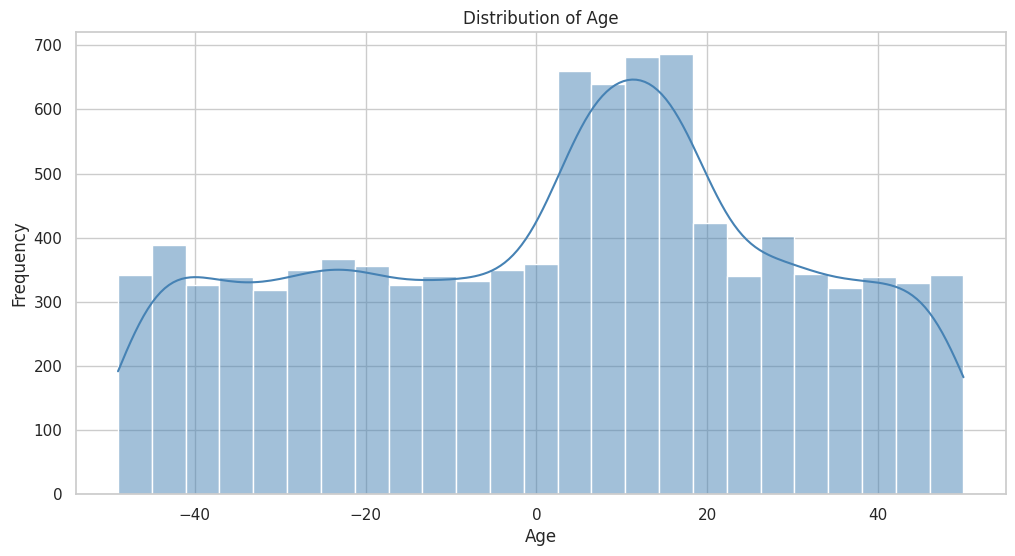

<ipython-input-79-ef9b67fd5541>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='pastel')


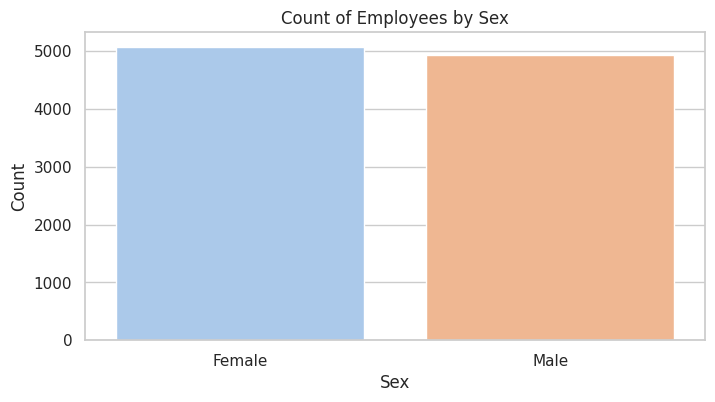

In [79]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Age'], kde=True, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Count plot for Sex
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Sex', palette='pastel')
plt.title('Count of Employees by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()




<ipython-input-80-23b0958efc8c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Job Title', order=df['Job Title'].value_counts().index, palette='muted')


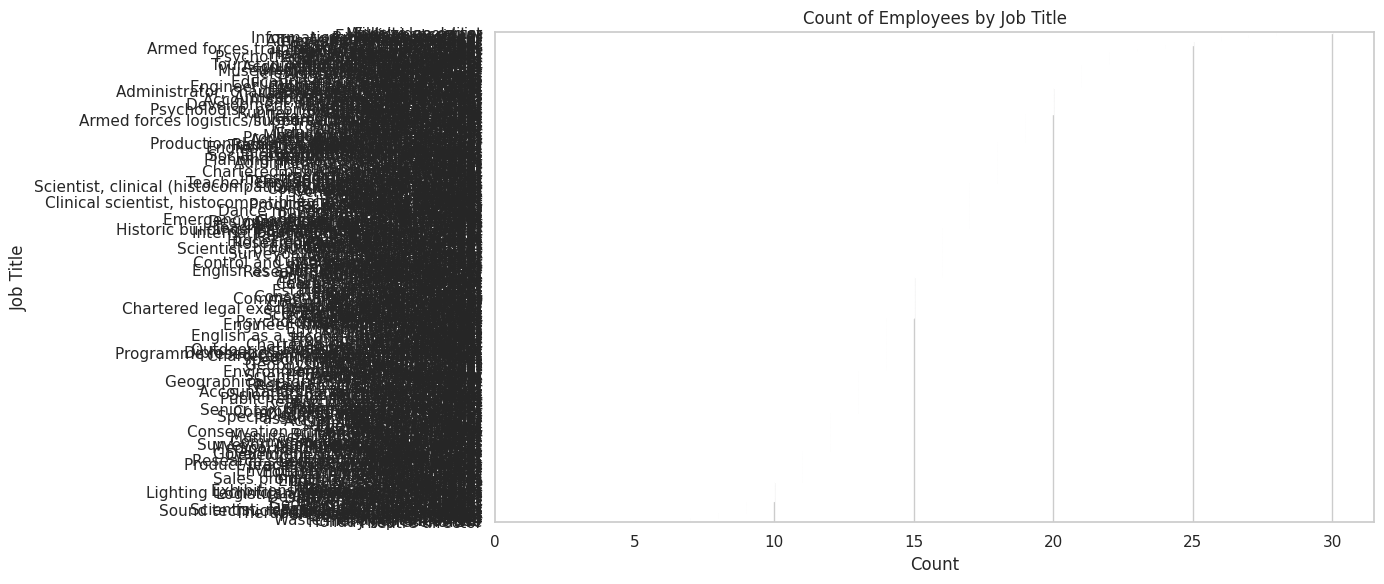

<ipython-input-80-23b0958efc8c>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sex', y='Age', palette='Set2')


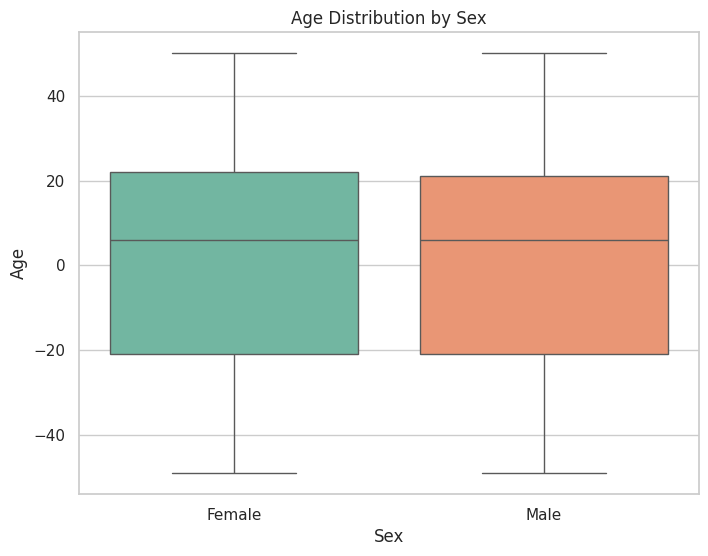

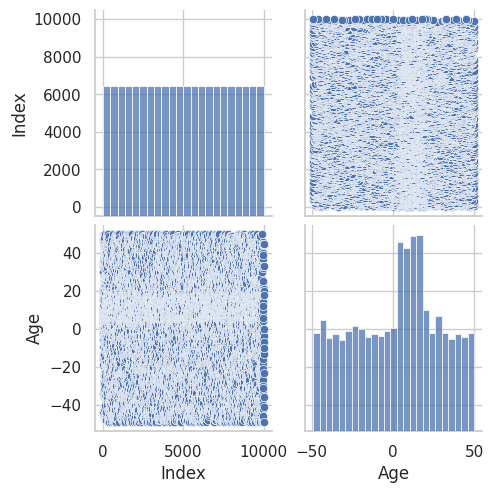

In [80]:
# Count plot for Job Title
plt.figure(figsize=(14, 6))
sns.countplot(data=df, y='Job Title', order=df['Job Title'].value_counts().index, palette='muted')
plt.title('Count of Employees by Job Title')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

# Box plot: Age distribution by Sex
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Sex', y='Age', palette='Set2')
plt.title('Age Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.show()


numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 2:
    sns.pairplot(numeric_df)
    plt.show()


Accuracy Score: 0.4856666666666667


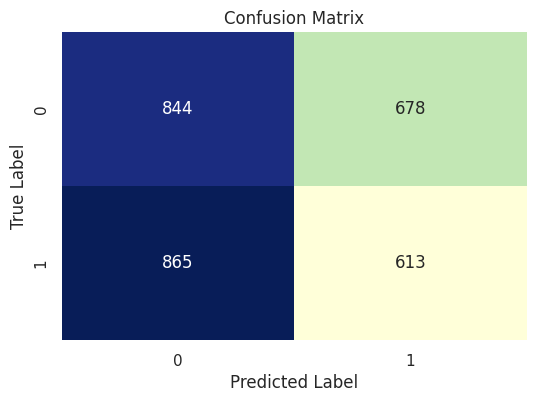


Classification Report:
              precision    recall  f1-score   support

      Female       0.49      0.55      0.52      1522
        Male       0.47      0.41      0.44      1478

    accuracy                           0.49      3000
   macro avg       0.48      0.48      0.48      3000
weighted avg       0.48      0.49      0.48      3000



In [81]:
features = df[['Age', 'Job Title']].copy()
target = df['Sex'].copy()

le = LabelEncoder()
target_encoded = le.fit_transform(target)

# One-hot encode - 'Job Title'
features_encoded = pd.get_dummies(features, columns=['Job Title'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(features_encoded, target_encoded, test_size=0.3, random_state=42, stratify=target_encoded)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score:', accuracy)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))


In [61]:
try:
    df['Email Domain'] = df['Email'].str.split('@').str[1]
    domain_counts = df['Email Domain'].value_counts()
    print("Email Domain Distribution:")
    print(domain_counts)
    print("\n")
except Exception as e:
    print(f"Error analyzing email domains: {e}")


Email Domain Distribution:
Email Domain
example.com    3433
example.org    3291
example.net    3276
Name: count, dtype: int64





Analysis complete.


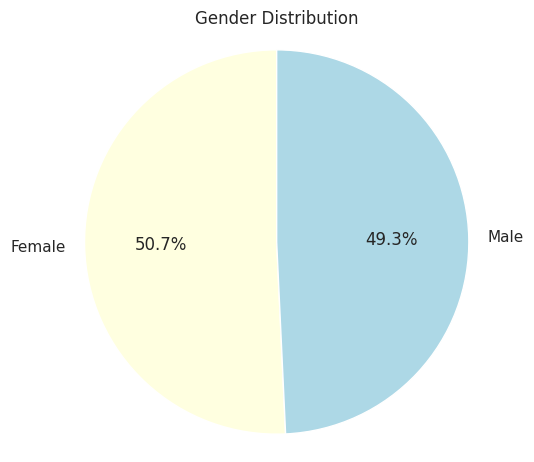

In [68]:
try:
    plt.figure(figsize=(12, 12))

    plt.subplot(2, 2, 1)
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['lightyellow', 'lightblue'])
    plt.title('Gender Distribution')
    plt.axis('equal')

except Exception as e:
    print(f"Error generating visualizations: {e}")

print("\nAnalysis complete.")

In [70]:
# Name length analysis
df['First Name Length'] = df['First Name'].str.len()
df['Last Name Length'] = df['Last Name'].str.len()
print("Name Length Statistics:")
print(f"Average first name length: {df['First Name Length'].mean():.1f} characters")
print(f"Average last name length: {df['Last Name Length'].mean():.1f} characters")

# First letter of name analysis
df['First Name Initial'] = df['First Name'].str[0]
first_initials = df['First Name Initial'].value_counts()
print("\nFirst Name Initial Distribution:")
print(first_initials)

# Gender ratio by job title
job_gender = pd.crosstab(df['Job Title'], df['Sex'])
print("\nGender Distribution by Job Title:")
print(job_gender)

Name Length Statistics:
Average first name length: 5.8 characters
Average last name length: 6.1 characters

First Name Initial Distribution:
First Name Initial
J    1000
C     969
M     903
A     785
S     767
D     715
K     673
B     625
T     560
R     528
L     454
G     357
E     343
P     289
H     217
N     206
V     132
W     131
F     126
I      90
Y      50
O      36
Z      28
X      16
Name: count, dtype: int64

Gender Distribution by Job Title:
Sex                               Female  Male
Job Title                                     
Academic librarian                     3    10
Accommodation manager                  8     4
Accountant, chartered                 10     5
Accountant, chartered certified        7    14
Accountant, chartered management       9    11
...                                  ...   ...
Water quality scientist                8    10
Web designer                           9     5
Wellsite geologist                    17    11
Writer                